# 15주차 실습 — LangGraph로 만드는 멀티턴 · 분기 챗봇

이 노트북은 **위에서부터 순서대로** 실행하세요. (셀 선택 후 `Shift + Enter`)

| Part | 내용 | 핵심 도구 |
| --- | --- | --- |
| Part 0 | 준비 (설치 · API 키 · 모델 확인) | `ChatGoogleGenerativeAI` |
| Part 1 | 멀티턴 챗봇 만들기 | `add_messages` |
| Part 2 | 대화 자동 기억하기 | `MemorySaver`, `thread_id` |
| Part 3 | 문서 Q&A(RAG) 챗봇 준비 | 간단 검색기 |
| Part 4 | 라우터 — 갈림길 판단 함수 | LLM 분류 |
| Part 5 | 전부 합치기 (완성 그래프) | `add_conditional_edges` |
| Part 6 | 그래프 시각화 | `draw_mermaid` |
| Part 7 | 실습 과제 | (직접 작성) |

> ⚠️ Part 1~7은 모두 **Part 0을 먼저 실행**해야 동작합니다. (llm 변수를 씁니다)

---
## Part 0. 준비

### 0-1. 라이브러리 설치

한 번만 실행하면 됩니다. 설치 후 **커널을 재시작**하면 더 안전합니다.

In [1]:
# -U : 이미 깔려 있어도 최신 버전으로 올린다
# langgraph            : 오늘의 주인공 (그래프 만들기)
# langchain            : 문서/벡터스토어 등 공통 부품
# langchain-google-genai : Gemini 모델과 임베딩을 쓰기 위한 연결부
!pip install -qU langgraph langchain langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 9.8 MB/s eta 0:00:00


### 0-2. API 키 입력

아래 셀을 실행하면 입력창이 뜹니다. 키를 붙여넣고 Enter를 누르세요.
(`getpass`를 쓰면 화면에 키가 보이지 않아 안전합니다.)

In [2]:
import os
from getpass import getpass

# 환경변수에 키를 넣어두면, 이후 모델을 만들 때 자동으로 이 값을 읽어간다
# 이미 키가 설정돼 있으면 다시 묻지 않는다
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass("Google API Key: ")

print("키 설정 완료")

Google API Key: ··········
키 설정 완료


### 0-3. 모델 준비 & 동작 확인

- **LLM**: 답변을 생성하는 모델
- **Embeddings**: 문장을 숫자 벡터로 바꿔 '의미가 비슷한 문서'를 찾게 해주는 모델 (Part 3에서 사용)

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

# 답변을 만드는 모델. 지원이 끝난 모델이면 최신 flash 계열로 바꾸면 된다
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

# 잘 연결됐는지 확인
# .text : 답변에서 글자만 꺼낸다  (.content 는 모델에 따라 리스트일 수 있어 .text 를 쓴다)
print(llm.invoke("한 문장으로 자기소개 해줘").text)

사용자의 궁금증을 명쾌하고 유익하게 해결해 주는 **만능 AI 어시스턴트**입니다.


> 💡 **답변 텍스트는 `.content` 말고 `.text` 로 꺼냅니다.**
> 최신 모델은 `.content`가 문자열이 아니라 리스트일 때가 있어서
> `'list' object has no attribute 'strip'` 같은 에러가 납니다. `.text`는 항상 문자열입니다.
>
> (혹시 `<bound method ...>` 처럼 출력되면 라이브러리가 구버전입니다. `.text()` 로 괄호를 붙이세요.)
>
> 📌 오늘은 **임베딩 API를 쓰지 않습니다.** Part 3의 문서 검색은 파이썬만으로 돌아가므로
> 임베딩 쪽 404 / 500 에러에 수업이 막히지 않습니다.

✅ 위 셀에서 답변이 출력되면 준비 완료입니다.

❌ 에러가 난다면:
- `InvalidArgument` / `API key not valid` → 키를 잘못 붙여넣었습니다. 0-2를 다시 실행하세요.
- `ModuleNotFoundError` → 0-1 설치 후 커널을 재시작하세요.

---
## Part 1. 멀티턴 챗봇 만들기

### 1-1. 먼저 '기억 못 하는 챗봇'을 확인해 봅시다

질문 한 줄만 넘기면 LLM은 앞의 대화를 알 수 없습니다.

In [4]:
# 매번 '이번 질문 한 줄'만 넘기는 방식
print(llm.invoke("내 이름은 김철수야.").text)
print("---")
print(llm.invoke("내 이름이 뭐라고?").text)   # ← 모름! (앞 대화를 안 넘겼으니까)

반가워요, 김철수님! 만나서 기쁩니다. 오늘 어떤 이야기를 나누고 싶으신가요? 편하게 말씀해 주세요!
---
죄송하지만, 제가 이전 대화에서 당신의 이름을 알게 된 적이 없다면 당신의 이름을 알지 못합니다. 

말씀해 주시면 기억하겠습니다! 성함이 어떻게 되시나요?


### 1-2. 해결책 — 대화 전체를 넘긴다

리스트에 지금까지의 대화를 담아 통째로 넘기면 기억합니다.

In [5]:
# 대화 한 줄 = 메시지 1개
#   role="user"      → 사람이 한 말
#   role="assistant" → LLM이 한 말
#   role="system"    → 봇의 성격/규칙
messages = [
    {"role": "user", "content": "내 이름은 김철수야."},
    {"role": "assistant", "content": "반갑습니다, 김철수님!"},
    {"role": "user", "content": "내 이름이 뭐라고?"},
]

print(llm.invoke(messages).text)   # ← 이번엔 기억한다

김철수님이요!


### 1-3. `add_messages` — 대화를 쌓아주는 리듀서

14주차에서 `operator.add`로 리스트를 이어붙였죠.
메시지에는 전용 리듀서 **`add_messages`** 가 있습니다.

```
■ 리듀서 없음 (덮어쓰기)
  [질문1] → 노드가 [답변1] 반환 → [답변1]           ❌ 질문이 사라짐

■ add_messages (이어붙이기)
  [질문1] → 노드가 [답변1] 반환 → [질문1, 답변1]     ✅ 쌓임
```

In [6]:
from typing import Annotated              # 타입에 '추가 정보'를 붙일 때 쓴다
from typing_extensions import TypedDict   # 상태(State)의 모양을 정의
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# ① State 정의 — 그래프가 들고 다니는 공유 메모장
class State(TypedDict):
    # Annotated[타입, 리듀서] 형태.
    # add_messages = "새 메시지가 오면 덮어쓰지 말고 뒤에 이어붙여라"
    messages: Annotated[list, add_messages]


# ② Node 정의 — 봇 한 명. 상태를 받아 '바뀔 부분만' 반환한다
def chatbot(state: State):
    # state["messages"] : 지금까지의 대화 전체
    response = llm.invoke(state["messages"])      # 통째로 LLM에 넘긴다
    return {"messages": [response]}               # 답변 1개만 반환 → 리듀서가 뒤에 붙여줌


# ③ 그래프 조립
builder = StateGraph(State)          # State 설계도를 알려주며 빌더 생성
builder.add_node("chatbot", chatbot) # 노드 등록: "이름" ← → 함수
builder.add_edge(START, "chatbot")   # 시작 → chatbot
builder.add_edge("chatbot", END)     # chatbot → 끝

graph = builder.compile()            # 완성 (아직 기억 기능은 없다)
print("그래프 완성")

그래프 완성


### 1-4. 실행 — 단, 대화 기록을 직접 들고 다녀야 한다

In [7]:
# 1턴
state = graph.invoke({"messages": [{"role": "user", "content": "내 이름은 김철수야."}]})
print("봇:", state["messages"][-1].text)   # [-1] = 가장 마지막 메시지 = 방금 나온 답변

# 2턴 — 앞 결과(state["messages"])에 새 질문을 직접 이어붙여서 넣어야 한다
state = graph.invoke({
    "messages": state["messages"] + [{"role": "user", "content": "내 이름이 뭐라고?"}]
})
print("봇:", state["messages"][-1].text)   # ← 기억함 ✅

# 상태에 몇 개가 쌓였는지 확인
print("\n쌓인 메시지 수:", len(state["messages"]))   # 질문2 + 답변2 = 4개

봇: 반가워요, 김철수 님! 만나서 기쁩니다. 오늘 어떤 일로 도와드릴까요?
봇: 김철수 님이죠! 기억하고 있습니다. ㅎㅎ

쌓인 메시지 수: 4


잘 동작하지만 **`state["messages"]`를 직접 들고 다니는 게 번거롭습니다.**
이걸 자동화하는 것이 Part 2의 체크포인터입니다.

---
## Part 2. 대화를 자동으로 기억하기 — 체크포인터

`compile()`에 **체크포인터**를 넣으면 LangGraph가 매 턴의 상태를 알아서 저장·복원합니다.

In [8]:
from langgraph.checkpoint.memory import MemorySaver

# MemorySaver : 대화 상태를 '메모리(램)'에 저장하는 가장 단순한 체크포인터
#               프로그램을 끄면 사라진다 (영구 저장은 SqliteSaver 등을 사용)
memory = MemorySaver()

# Part 1에서 만든 builder를 그대로 재사용하되, 체크포인터만 붙여서 다시 컴파일
graph = builder.compile(checkpointer=memory)   # ← 이 한 줄이 전부

print("기억하는 그래프 완성")

기억하는 그래프 완성


### 2-1. `thread_id` = 대화방 번호

체크포인터를 붙이면 **실행할 때마다 `config`로 대화방 번호를 알려줘야** 합니다.

```
thread_id="user-1" ──→ 📁 [질문1, 답변1, 질문2, 답변2, ...]
thread_id="user-2" ──→ 📁 [ ... 완전히 별개의 대화 ... ]
```

In [9]:
# config의 모양은 고정: {"configurable": {"thread_id": "아무 문자열"}}
config = {"configurable": {"thread_id": "user-1"}}

# 1턴 — 새 질문만 넣는다 (앞 대화를 직접 챙기지 않아도 된다!)
r = graph.invoke({"messages": [{"role": "user", "content": "내 이름은 김철수야."}]}, config)
print("봇:", r["messages"][-1].text)

# 2턴 — 역시 새 질문만. 앞 대화는 체크포인터가 알아서 꺼내 붙여준다
r = graph.invoke({"messages": [{"role": "user", "content": "내 이름이 뭐라고?"}]}, config)
print("봇:", r["messages"][-1].text)   # ← 기억함 ✅

봇: 반가워요, 김철수 님! 만나서 기쁩니다. 오늘 어떤 일로 도와드릴까요?
봇: 김철수 님이죠! 기억하고 있습니다. ㅎㅎ


In [10]:
# thread_id를 바꾸면 = 완전히 새로운 대화방
config2 = {"configurable": {"thread_id": "user-2"}}

r = graph.invoke({"messages": [{"role": "user", "content": "내 이름이 뭐라고?"}]}, config2)
print("봇:", r["messages"][-1].text)   # ← 모름 (다른 방이니까)

봇: 죄송하지만, 이전 대화 내용이 없어서 고객님의 이름을 알 수 없습니다. 

말씀해 주시면 기억할게요! 성함이 어떻게 되시나요?


### 2-2. 저장된 대화 들여다보기

`get_state()`로 현재 대화방에 무엇이 쌓여 있는지 확인할 수 있습니다.

In [11]:
# 특정 thread의 현재 상태를 꺼내 본다
snapshot = graph.get_state(config)

for m in snapshot.values["messages"]:
    # m.type : "human"(사람) 또는 "ai"(LLM)
    print(f"[{m.type}] {m.text}")

[human] 내 이름은 김철수야.
[ai] 반가워요, 김철수 님! 만나서 기쁩니다. 오늘 어떤 일로 도와드릴까요?
[human] 내 이름이 뭐라고?
[ai] 김철수 님이죠! 기억하고 있습니다. ㅎㅎ


### 2-3. 터미널 대화 루프

이제 진짜 챗봇처럼 여러 턴을 이어서 대화해 봅시다.
**`종료`를 입력하면 빠져나옵니다.**

In [12]:
# 새 대화방을 하나 파고 시작
chat_config = {"configurable": {"thread_id": "demo"}}

while True:
    user_input = input("나: ")

    # 종료 조건 — 무한 루프는 반드시 빠져나갈 길을 만들어 둔다
    if user_input.strip().lower() in ("quit", "exit", "종료"):
        print("대화를 종료합니다.")
        break

    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, chat_config)
    print("봇:", result["messages"][-1].text)

KeyboardInterrupt: Interrupted by user

---
## Part 3. 문서 Q&A(RAG) 챗봇 준비

분기의 다른 한쪽인 **문서 기반 챗봇**을 만들어 둡니다.
11~13주차에서 배운 RAG를 아주 작게 재현합니다.

```
질문 → [검색] 관련 문서 2개 → [프롬프트에 끼워넣기] → [LLM] → 답변
```

In [13]:
from langchain_core.documents import Document

# ① 문서 창고 — 실제로는 PDF/웹페이지를 잘라 넣지만, 오늘은 문장 4개로 충분하다
docs = [
    "우리 학원의 수강료 환불은 개강일로부터 7일 이내에 신청하면 전액 환불됩니다.",
    "수업은 매주 화요일과 목요일 저녁 7시부터 10시까지 진행됩니다.",
    "결석 시 녹화 영상이 제공되며, 링크는 수업 다음 날 오전에 발송됩니다.",
    "수료 조건은 전체 수업의 80% 이상 출석과 최종 프로젝트 제출입니다.",
]


# ② 검색기 — 질문과 겹치는 글자가 많은 문장을 k개 골라준다
class SimpleRetriever:
    def __init__(self, texts, k=2):
        self.texts = texts
        self.k = k

    def _score(self, text, query):
        # 질문을 두 글자씩 쪼개서 점수를 매긴다.
        # 여러 문장에 흔히 나오는 조각("하면", "니다"...)은 점수를 낮게 준다
        score = 0
        for i in range(len(query) - 1):
            gram = query[i:i + 2]
            common = sum(gram in t for t in self.texts)   # 몇 개 문장에 들어있나
            if common and gram in text:
                score += 1 / common
        return score

    def invoke(self, query):
        ranked = sorted(self.texts, key=lambda t: -self._score(t, query))
        return [Document(page_content=t) for t in ranked[:self.k]]


retriever = SimpleRetriever(docs)

print("문서 창고 준비 완료:", len(docs), "개 문장")

문서 창고 준비 완료: 4 개 문장


> 💡 **왜 임베딩(벡터 검색)을 안 쓰나요?**
>
> 11~13주차에서 배운 벡터 검색이 정석이지만, 임베딩 API는 키·모델명·서버 상태에 따라
> 자주 막힙니다. 오늘의 주제는 **그래프 분기**이지 검색 성능이 아니므로,
> 파이썬만으로 도는 간단 검색기를 씁니다. `retriever.invoke(질문)` 사용법은 똑같습니다.
>
벡터 검색으로 바꾸고 싶다면 위 셀의 ②만 아래로 교체하면 됩니다. (나머지는 그대로)

```python
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vectorstore = InMemoryVectorStore.from_texts(docs, embedding=embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})
```

In [14]:
# 검색이 잘 되는지 먼저 확인
for d in retriever.invoke("환불 규정이 어떻게 되나요?"):
    print("-", d.page_content)

- 우리 학원의 수강료 환불은 개강일로부터 7일 이내에 신청하면 전액 환불됩니다.
- 결석 시 녹화 영상이 제공되며, 링크는 수업 다음 날 오전에 발송됩니다.


### 3-1. RAG 노드 만들기

노드는 그냥 함수입니다. 안에서 **검색 → 프롬프트 조립 → LLM 호출** 을 하면 됩니다.

> 📌 중요: 이 노드도 **`messages`를 받아 `messages`를 반환**합니다.
> Part 1의 챗봇 노드와 **입출력 모양이 똑같기 때문에** 나중에 갈아 끼울 수 있습니다.

> 📌 아래 테스트 셀에서 `HumanMessage`를 쓰는 이유
>
> 그래프 안에서는 `add_messages`가 딕셔너리를 메시지 객체로 바꿔주지만,
> **함수를 직접 호출할 때는** 바꿔줄 사람이 없습니다.
> 그래서 단독 테스트에서는 `HumanMessage("질문")` 으로 넣어줍니다.

In [15]:
def rag_bot(state: State):
    # ① 마지막 사용자 질문을 꺼낸다
    question = state["messages"][-1].text

    # ② 관련 문서를 검색해서 하나의 문자열로 합친다
    found = retriever.invoke(question)
    context = "\n".join(d.page_content for d in found)

    # ③ '자료 + 질문'을 하나의 프롬프트로 조립
    #    "자료에 없으면 모른다고 답하라"는 지시가 환각(hallucination)을 줄여준다
    prompt = f"""아래 자료만 근거로 질문에 답하세요.
자료에 없으면 "자료에서 찾을 수 없습니다"라고 답하세요.

[자료]
{context}

[질문] {question}"""

    # ④ LLM 호출 후, 답변 1개만 반환 → add_messages가 뒤에 이어붙여 준다
    return {"messages": [llm.invoke(prompt)]}


# 그래프에 넣기 전에 함수만 따로 테스트해 보는 습관을 들이자
from langchain_core.messages import HumanMessage   # 사람이 한 말을 나타내는 메시지

test_state = {"messages": [HumanMessage("환불 언제까지 돼요?")]}
print(rag_bot(test_state)["messages"][0].text)

개강일로부터 7일 이내에 신청하면 됩니다.


In [16]:
# 자료에 없는 질문을 하면? → "찾을 수 없습니다"라고 답해야 정상
test_state = {"messages": [HumanMessage("주차장은 어디에 있나요?")]}
print(rag_bot(test_state)["messages"][0].text)

자료에서 찾을 수 없습니다.


---
## Part 4. 라우터 — 갈림길 판단하기

14주차에서 배운 라우터와 **똑같습니다.** 상태를 보고 **이름표(문자열)** 를 반환하면 끝.
다만 이번에는 판단을 **LLM에게 맡깁니다.**

```
              ┌──(chat)──→ 일반 대화 챗봇
질문 → route ─┤
              └──(docs)──→ 문서 Q&A 챗봇
```

In [17]:
# 라우터용 프롬프트
# 포인트 1: 선택지를 명확히 나열한다
# 포인트 2: "단어 하나만 출력하라"고 못 박는다 (뒤에서 파싱하기 쉽게)
ROUTER_PROMPT = """사용자 질문을 두 가지 중 하나로 분류하세요.

- docs : 학원 운영(수강료, 환불, 수업 시간, 출석, 수료, 결석)에 관한 질문
- chat : 그 외 모든 일반 대화, 잡담, 상식 질문

반드시 docs 또는 chat 이라는 단어 하나만 출력하세요.

질문: {question}"""


def route(state: State):
    question = state["messages"][-1].text

    # LLM에게 분류를 맡긴다
    answer = llm.invoke(ROUTER_PROMPT.format(question=question)).text

    # LLM은 가끔 "docs입니다." 처럼 군더더기를 붙인다.
    # 그래서 == 대신 in 으로 느슨하게 검사하고,
    # 애매하면 안전한 기본값(chat)으로 보낸다.
    answer = answer.strip().lower()
    return "docs" if "docs" in answer else "chat"


print("라우터 준비 완료")

라우터 준비 완료


In [18]:
# 그래프에 넣기 전에 라우터만 따로 테스트 — 분기가 엉뚱하면 여기서 잡는다
tests = [
    "환불 언제까지 돼요?",
    "오늘 날씨 어때?",
    "수료하려면 몇 번 나와야 해?",
    "심심해, 재밌는 얘기 해줘",
    "결석하면 어떻게 돼?",
]

for t in tests:
    result = route({"messages": [HumanMessage(t)]})   # 단독 호출이므로 HumanMessage
    print(f"{result:>5}  ←  {t}")

 docs  ←  환불 언제까지 돼요?
 chat  ←  오늘 날씨 어때?
 docs  ←  수료하려면 몇 번 나와야 해?
 chat  ←  심심해, 재밌는 얘기 해줘
 docs  ←  결석하면 어떻게 돼?


---
## Part 5. 전부 합치기 — 완성 그래프

재료가 다 모였습니다. 조립만 하면 됩니다.

```
                    ┌──(chat)──→ [chat_bot] ──┐
START ──(route)─────┤                          ├──→ END
                    └──(docs)──→ [rag_bot]  ──┘

  + checkpointer(MemorySaver) → thread_id 별로 대화 기억
```

In [19]:
# ① 상태 — Part 1과 동일 (대화 기록을 쌓는다)
class State(TypedDict):
    messages: Annotated[list, add_messages]


# ② 노드 1 — 일반 대화 챗봇
#    system 메시지로 봇의 성격을 정해준다. 매번 대화 맨 앞에 붙여서 보낸다
SYSTEM = {"role": "system", "content": "너는 친절한 학습 도우미야. 한국어로 간결하게 답해."}

def chat_bot(state: State):
    response = llm.invoke([SYSTEM] + state["messages"])   # 성격 + 지금까지의 대화 전체
    return {"messages": [response]}


# ③ 노드 2 — 문서 Q&A 챗봇 (Part 3에서 만든 rag_bot을 그대로 사용)
# ④ 라우터    — (Part 4에서 만든 route를 그대로 사용)


# ⑤ 조립
builder = StateGraph(State)
builder.add_node("chat_bot", chat_bot)   # 봇 2명을 노드로 등록
builder.add_node("rag_bot", rag_bot)

# 조건 엣지: START에서 route()를 실행하고,
#            반환된 이름표를 지도(dict)에 따라 실제 노드로 연결한다
#            ⚠️ route()의 반환 문자열과 지도의 '키'가 정확히 일치해야 한다
builder.add_conditional_edges(START, route, {"chat": "chat_bot", "docs": "rag_bot"})

# 두 봇 모두 답변 후 종료
builder.add_edge("chat_bot", END)
builder.add_edge("rag_bot", END)

# ⑥ 컴파일 — 체크포인터를 붙여 대화를 기억하게 한다
graph = builder.compile(checkpointer=MemorySaver())

print("완성!")

완성!


### 5-1. 대화해 보기

두 봇이 **하나의 대화 기록(`messages`)을 공유**하므로,
중간에 RAG 쪽으로 갔다 와도 앞선 대화를 기억합니다.

In [20]:
config = {"configurable": {"thread_id": "steve"}}

def say(text):
    """한 턴 대화하고 결과를 예쁘게 출력하는 도우미 함수"""
    result = graph.invoke({"messages": [{"role": "user", "content": text}]}, config)
    print("나 :", text)
    print("봇 :", result["messages"][-1].text)
    print("-" * 60)

say("안녕! 내 이름은 김철수야.")     # → chat_bot 으로 갈 것
say("환불은 언제까지 가능해?")        # → rag_bot 으로 갈 것 (문서 검색)
say("수료 조건도 알려줘")             # → rag_bot
say("내 이름 기억해?")                # → chat_bot, 그런데 이름을 기억함 ✅

나 : 안녕! 내 이름은 김철수야.
봇 : 반가워, 철수야! 만나서 기뻐. 
오늘 어떤 공부를 도와줄까?
------------------------------------------------------------
나 : 환불은 언제까지 가능해?
봇 : 개강일로부터 7일 이내에 신청하면 가능합니다.
------------------------------------------------------------
나 : 수료 조건도 알려줘
봇 : 수료 조건은 전체 수업의 80% 이상 출석과 최종 프로젝트 제출입니다.
------------------------------------------------------------
나 : 내 이름 기억해?
봇 : 물론이지! 철수잖아. 또 궁금한 거 있어?
------------------------------------------------------------


### 5-2. 어느 길로 갔는지 눈으로 보기

`invoke` 대신 `stream`을 쓰면 **실행된 노드 이름**이 보입니다.
분기가 의도대로 됐는지 확인할 때 유용합니다.

In [21]:
config2 = {"configurable": {"thread_id": "trace"}}

for question in ["결석하면 어떻게 돼?", "좋아하는 색이 뭐야?"]:
    print(f"\n질문: {question}")

    # stream은 노드가 하나 끝날 때마다 {노드이름: 결과} 형태로 내보낸다
    for chunk in graph.stream({"messages": [{"role": "user", "content": question}]}, config2):
        for node_name, value in chunk.items():
            preview = value["messages"][-1].text[:60].replace("\n", " ")
            print(f"  → 실행된 노드 [{node_name}] : {preview}...")


질문: 결석하면 어떻게 돼?
  → 실행된 노드 [rag_bot] : 결석 시 녹화 영상이 제공되며, 링크는 수업 다음 날 오전에 발송됩니다....

질문: 좋아하는 색이 뭐야?
  → 실행된 노드 [chat_bot] : 저는 인공지능이라 색을 직접 볼 수는 없지만, 학습자님들이 가장 많이 찾는 **파란색**을 좋아해요! 신뢰감...


### 5-3. 완성된 챗봇과 자유 대화

`종료`를 입력하면 빠져나옵니다.

In [22]:
free_config = {"configurable": {"thread_id": "free-talk"}}

print("학원 규정을 물어보면 문서에서 찾고, 그 외에는 일반 대화를 합니다. ('종료' 입력 시 끝)\n")

while True:
    user_input = input("나: ")
    if user_input.strip().lower() in ("quit", "exit", "종료"):
        print("대화를 종료합니다.")
        break

    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, free_config)
    print("봇:", result["messages"][-1].text, "\n")

학원 규정을 물어보면 문서에서 찾고, 그 외에는 일반 대화를 합니다. ('종료' 입력 시 끝)



KeyboardInterrupt: Interrupted by user

---
## Part 6. 그래프 시각화

내가 만든 그래프가 실제로 어떻게 생겼는지 확인합니다.
그래프가 복잡해질수록 이 확인이 큰 도움이 됩니다.

In [23]:
# mermaid 문법의 텍스트로 출력.
# 출력 결과를 https://mermaid.live 에 붙여넣으면 그림으로 볼 수 있다
# 점선(-.->)은 조건 분기, 실선(-->)은 일반 엣지를 뜻한다
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chat_bot(chat_bot)
	rag_bot(rag_bot)
	__end__([<p>__end__</p>]):::last
	__start__ -. &nbsp;chat&nbsp; .-> chat_bot;
	__start__ -. &nbsp;docs&nbsp; .-> rag_bot;
	chat_bot --> __end__;
	rag_bot --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



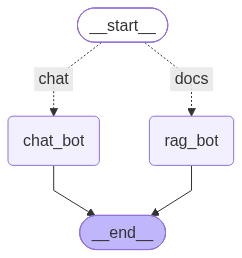

In [24]:
# 노트북에서 이미지로 바로 보기 (인터넷 연결 필요)
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # 렌더링 서버 접속이 안 될 수 있으니, 실패해도 실습에는 지장 없다
    print("이미지 렌더링 실패:", e)
    print("→ 위 셀의 mermaid 텍스트를 mermaid.live 에 붙여넣어 확인하세요.")

---
## Part 7. 실습 과제

### [기본] 세 번째 봇 추가하기

"요약해줘 / 정리해줘" 같은 요청이 오면 **지금까지의 대화를 3줄로 요약**하는 `summary_bot`을 추가하세요.

**힌트 — 고쳐야 할 곳은 딱 3군데입니다.**
1. `summary_bot` 함수 작성
2. `ROUTER_PROMPT`에 `summary` 선택지 추가 + `route`에서 반환
3. `add_node` 1줄 추가, 조건 엣지 지도에 `"summary": "summary_bot"` 추가

In [25]:
# ─────────── [기본] 과제 — 빈칸을 채워 완성하세요 ───────────

# 1) 요약 봇
def summary_bot(state: State):
    # 지금까지의 대화를 하나의 글로 합친다
    history = "\n".join(f"{m.type}: {m.text}" for m in state["messages"])

    prompt = f"""아래 대화를 3줄로 요약하세요.

{history}"""

    return {"messages": [llm.invoke(prompt)]}


# 2) 라우터 프롬프트 수정  ← TODO: summary 선택지를 추가하세요
ROUTER_PROMPT_V2 = """사용자 질문을 세 가지 중 하나로 분류하세요.

- docs    : 학원 운영(수강료, 환불, 수업 시간, 출석, 수료, 결석)에 관한 질문
- summary : 지금까지의 대화를 요약/정리해 달라는 요청
- chat    : 그 외 모든 일반 대화, 잡담, 상식 질문

반드시 docs, summary, chat 중 단어 하나만 출력하세요.

질문: {question}"""


def route_v2(state: State):
    question = state["messages"][-1].text
    answer = llm.invoke(ROUTER_PROMPT_V2.format(question=question)).text.strip().lower()

    # TODO: summary 판정을 추가하세요 (순서 주의 — 먼저 검사한 것이 우선)
    if "summary" in answer:
        return "summary"
    elif "docs" in answer:
        return "docs"
    else:
        return "chat"


# 3) 그래프 다시 조립  ← TODO: summary_bot을 노드로 등록하고 지도에 연결하세요
builder2 = StateGraph(State)
builder2.add_node("chat_bot", chat_bot)
builder2.add_node("rag_bot", rag_bot)
builder2.add_node("summary_bot", summary_bot)          # ← 추가

builder2.add_conditional_edges(
    START, route_v2,
    {"chat": "chat_bot", "docs": "rag_bot", "summary": "summary_bot"},   # ← 추가
)
builder2.add_edge("chat_bot", END)
builder2.add_edge("rag_bot", END)
builder2.add_edge("summary_bot", END)

graph2 = builder2.compile(checkpointer=MemorySaver())
print("3-봇 그래프 완성")

3-봇 그래프 완성


In [ ]:
# 테스트 — 대화를 몇 번 나눈 뒤 요약을 요청해 보세요
cfg = {"configurable": {"thread_id": "hw-basic"}}

def say2(text):
    r = graph2.invoke({"messages": [{"role": "user", "content": text}]}, cfg)
    print("나 :", text)
    print("봇 :", r["messages"][-1].text)
    print("-" * 60)

say2("안녕, 나는 파이썬을 배우고 있어.")
say2("환불 규정이 어떻게 돼?")
say2("지금까지 대화 정리해줘")        # → summary_bot 으로 가야 정답

나 : 안녕, 나는 파이썬을 배우고 있어.
봇 : 안녕하세요! 파이썬 공부를 응원합니다. 

궁금한 점이 있다면 언제든 편하게 물어보세요. 쉽고 친절하게 알려드릴게요!
------------------------------------------------------------
나 : 환불 규정이 어떻게 돼?
봇 : 개강일로부터 7일 이내에 신청하면 전액 환불됩니다.
------------------------------------------------------------


### [응용] 내 주제로 바꾸기

`docs` 리스트를 여러분의 관심 분야(동아리 규정, 게임 공략, 회사 복지 등)로 바꾸고 **5문장 이상** 넣어 보세요.

> ⚠️ 문서를 바꾸면 **라우터 프롬프트의 `docs` 설명도 함께 고쳐야** 분기가 제대로 됩니다.
> (라우터는 문서 내용을 모르고, 설명만 보고 판단합니다)

In [ ]:
# ─────────── [응용] 과제 ───────────

my_docs = [
    # TODO: 여기에 여러분의 주제로 5문장 이상 작성하세요
    "예) 우리 동아리 정기 모임은 매주 수요일 오후 6시입니다.",
]

my_retriever = SimpleRetriever(my_docs)

# 검색이 잘 되는지 확인
for d in my_retriever.invoke("모임 언제야?"):
    print("-", d.page_content)

# TODO: rag_bot이 my_retriever를 쓰도록 고치고, ROUTER_PROMPT의 docs 설명도 바꿔보세요

### [도전] RAG가 못 찾으면 일반 챗봇에게 넘기기

`rag_bot`이 "자료에서 찾을 수 없습니다"라고 답하면, `chat_bot`으로 한 번 더 보내
일반 지식으로 답하게 만들어 보세요.

```
START ──(route)──→ [rag_bot] ──(못 찾음)──→ [chat_bot] ──→ END
                       │
                       └──(찾음)──→ END
```

**힌트**: `rag_bot` 뒤에 조건 엣지를 하나 더 답니다. 14주차 7절의 루프와 같은 원리입니다.

In [ ]:
# ─────────── [도전] 과제 ───────────

def check_rag_result(state: State):
    """rag_bot의 답변을 보고 다음 행선지를 정하는 라우터"""
    last_answer = state["messages"][-1].text

    # TODO: 답변에 "찾을 수 없" 이 들어있으면 "fallback", 아니면 "done"을 반환하세요
    if "찾을 수 없" in last_answer:
        return "fallback"
    return "done"


# TODO: 아래 그래프를 완성하세요
# builder3 = StateGraph(State)
# builder3.add_node("rag_bot", rag_bot)
# builder3.add_node("chat_bot", chat_bot)
# builder3.add_conditional_edges(START, route, {"chat": "chat_bot", "docs": "rag_bot"})
# builder3.add_conditional_edges("rag_bot", check_rag_result, {"fallback": "chat_bot", "done": END})
# builder3.add_edge("chat_bot", END)
# graph3 = builder3.compile(checkpointer=MemorySaver())

---
## 정리 — 오늘 외울 것은 이 다섯 줄

```python
# ① 상태 = 대화 기록
class State(TypedDict):
    messages: Annotated[list, add_messages]

# ② 봇 = 함수 (messages 받아 messages 반환)
def some_bot(state):
    return {"messages": [llm.invoke(state["messages"])]}

# ③ 라우터 = 이름표(문자열) 반환
def route(state): ...

# ④ 조립 + 기억
builder.add_conditional_edges(START, route, {"chat": "chat_bot", "docs": "rag_bot"})
graph = builder.compile(checkpointer=MemorySaver())

# ⑤ 실행 (thread_id 필수)
graph.invoke({"messages": [{"role": "user", "content": "..."}]},
             {"configurable": {"thread_id": "user-1"}})
```

### 문제가 생기면

| 증상 | 해결 |
| --- | --- |
| 앞 대화를 기억 못 함 | `compile(checkpointer=MemorySaver())` 확인 |
| 남의 대화가 섞임 | `thread_id`를 사용자마다 다르게 |
| 질문이 사라지고 답변만 남음 | `Annotated[list, add_messages]` 확인 |
| 항상 한쪽 봇으로만 감 | 라우터 반환값과 지도의 키가 같은지 확인 |
| 문서에 있는데 못 찾음 | `search_kwargs={"k": 3}` 으로 늘려보기 |
| `404 NOT_FOUND ... embedding` | 임베딩 모델을 `models/gemini-embedding-001` 로 |
| `'list' object has no attribute 'strip'` | `.content` 대신 `.text` 사용 |
| 임베딩 `404` / `500` 에러 | 오늘 자료는 임베딩을 쓰지 않는다. Part 3 셀을 그대로 사용 |
| `'dict' object has no attribute 'text'` | 노드 단독 테스트 시 `HumanMessage("...")` 로 넣기 |

수고하셨습니다! 🎉